- размеры датасетов
- число классов
- баланс классов на трейне и тесте
- распределение длин
- качество logreg+tfidf
- посмотреть на выбросы по длине

отдельно посмотреть oos и multilabel датасеты

In [3]:
single_label_datasets = ["DeepPavlov/banking77", "DeepPavlov/minds14", "DeepPavlov/hwu64", "DeepPavlov/snips", "DeepPavlov/massive"]
multi_label_datasets = ["DeepPavlov/events", "DeepPavlov/dstc3", "DeepPavlov/reuters"]
oos_datasets = ["DeepPavlov/clinc150"]

In [4]:
tokenizers_names = ["answerdotai/ModernBERT-base", "google-bert/bert-base-uncased", "openai-community/gpt2", "Qwen/QwQ-32B"]

In [2]:
import datasets
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
import numpy as np

sns.set_style("whitegrid")

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


## `Баланс классов`

In [6]:
def get_number_of_classes(ds: datasets.Dataset):
    return len(ds.unique("label"))

In [4]:
def plot_class_balance(ds: datasets.DatasetDict, suptitle: str | None = None):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    
    sns.histplot(ds["train"]["label"], bins=get_number_of_classes(ds["train"]), ax=ax[0])
    ax[0].set_title("Train Set")
    ax[0].set_xlabel("class id")
    sns.histplot(ds["test"]["label"], bins=get_number_of_classes(ds["test"]), ax=ax[1])
    ax[1].set_title("Test Set")
    ax[1].set_xlabel("class id")

    if suptitle is not None:
        fig.suptitle(suptitle)

    plt.show()

In [5]:
def plot_all_class_balances(datasets_names: list[str]):
    for name in datasets_names:
        plot_class_balance(datasets.load_dataset(name), name)

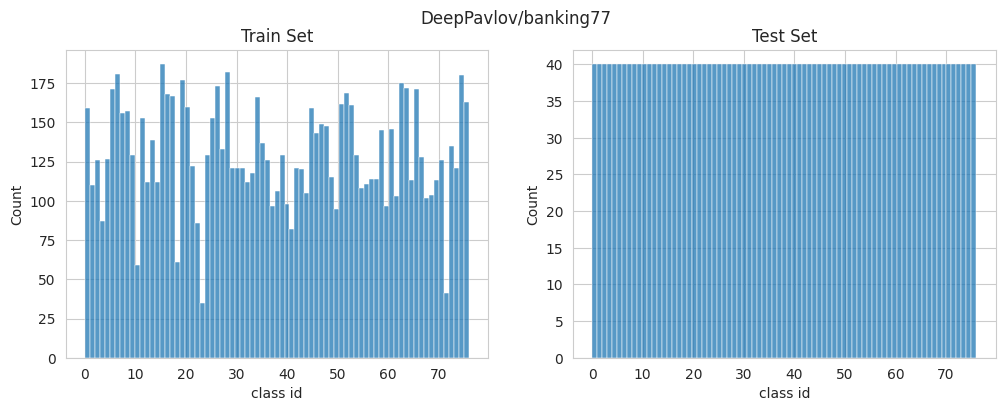

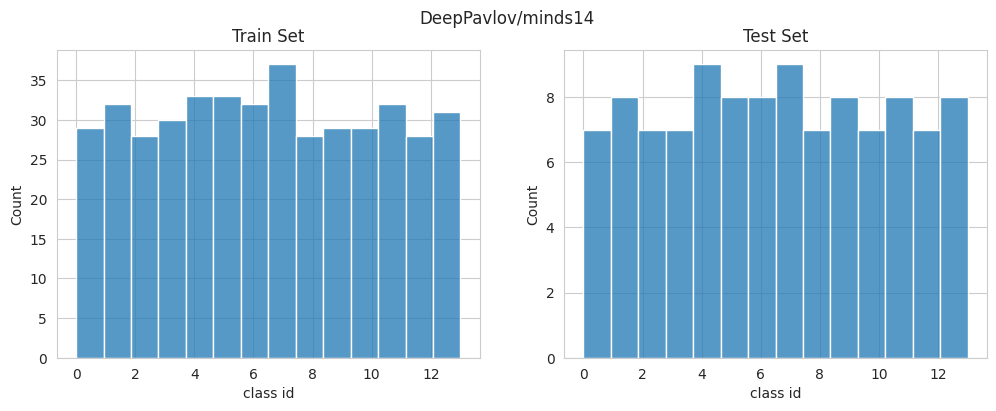

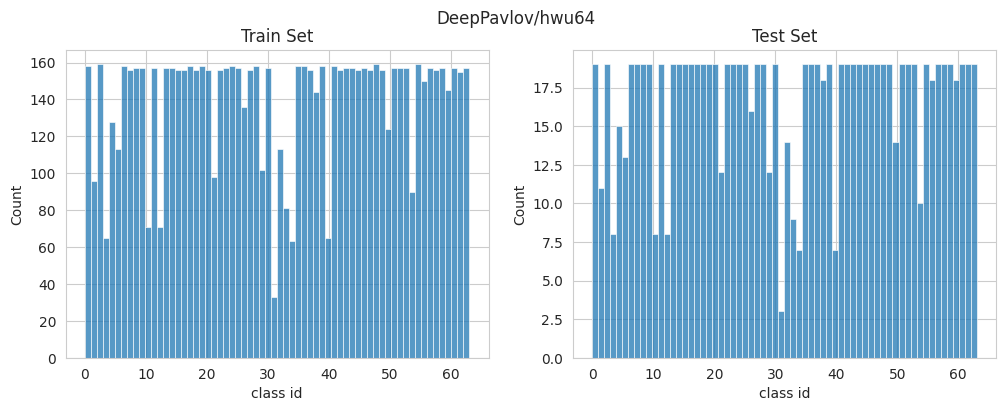

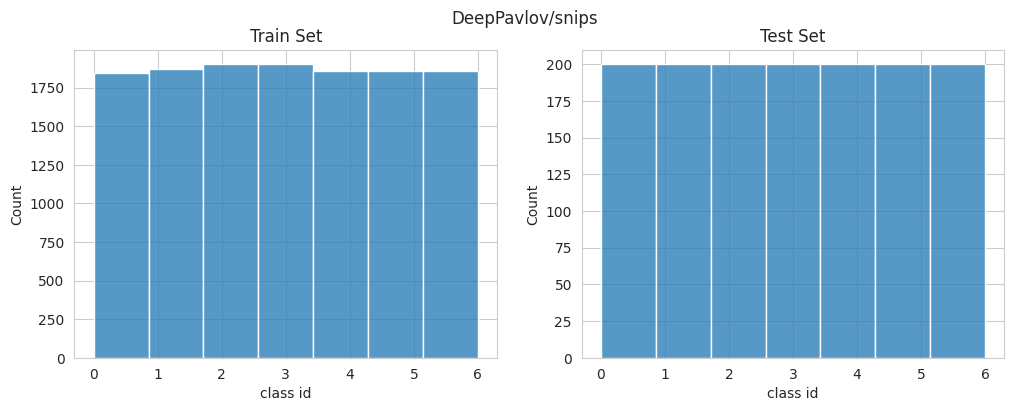

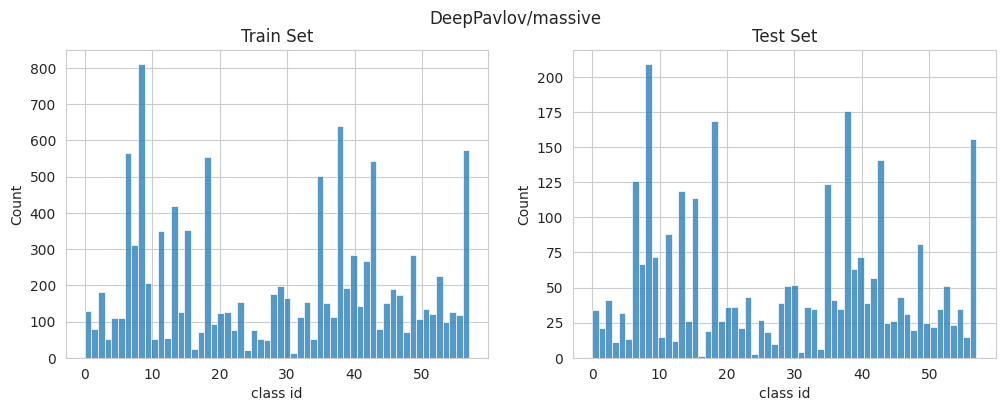

In [26]:
plot_all_class_balances(single_label_datasets)

## `Размеры датасетов`

In [6]:
def plot_datasets_sizes(datasets_names: list[str]):
    train_sizes = []
    test_sizes = []
    
    for name in datasets_names:
        ds = datasets.load_dataset(name)
        train_size = len(ds['train'])
        test_size = len(ds['test'])
        train_sizes.append(train_size)
        test_sizes.append(test_size)
    
    # Plotting
    x = range(len(datasets_names))
    width = 0.35  # Width of the bars
    
    fig, ax = plt.subplots()
    rects1 = ax.bar([i - width/2 for i in x], train_sizes, width, label='Train')
    rects2 = ax.bar([i + width/2 for i in x], test_sizes, width, label='Test')
    
    # Add some text for labels, title, and custom x-axis tick labels, etc.
    ax.set_xlabel('Datasets')
    ax.set_ylabel('Number of Samples')
    ax.set_title('Train and Test Sizes of Datasets')
    ax.set_xticks(x)
    ax.set_xticklabels(datasets_names, rotation=30, ha='right')
    ax.legend()
    
    # Add counts on top of the bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate('{}'.format(height),
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')
    
    autolabel(rects1)
    autolabel(rects2)
    
    fig.tight_layout()
    plt.show()


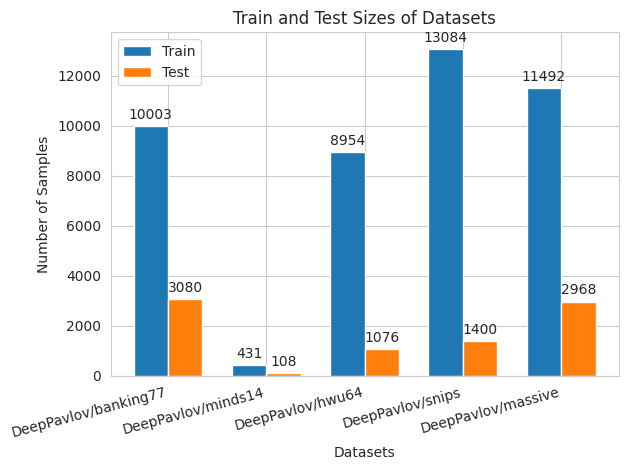

In [34]:
plot_datasets_sizes(single_label_datasets)

## `Длины датасетов`

In [8]:
def plot_tokens_distributions(datasets_names: list[str], tokenizer_name: str):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    for name in datasets_names:
        ds = datasets.load_dataset(name)
        
        # Tokenize the text and count the number of tokens
        n_tokens_train = [len(tokenizer.encode(rec["utterance"])) for rec in ds["train"]]
        n_tokens_test = [len(tokenizer.encode(rec["utterance"])) for rec in ds["test"]]
        
        # Create a figure and axis
        plt.figure(figsize=(5, 3))
        plt.title(f"Token Length Distribution for {name}")
        plt.xlabel("Number of Tokens")
        plt.ylabel("Density")
        
        # Plot the histograms
        sns.histplot(n_tokens_train, kde=True, color="blue", label="Train", stat="density", common_norm=False)
        sns.histplot(n_tokens_test, kde=True, color="orange", label="Test", stat="density", common_norm=False)
        
        # Add a legend
        plt.legend()
        
        # Show the plot
        plt.show()

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


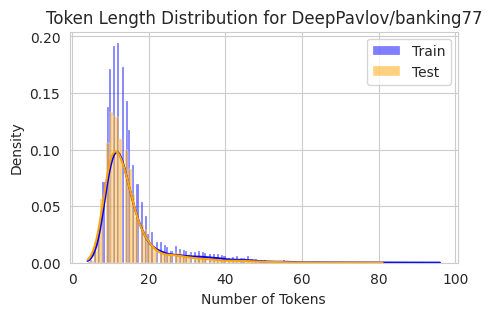

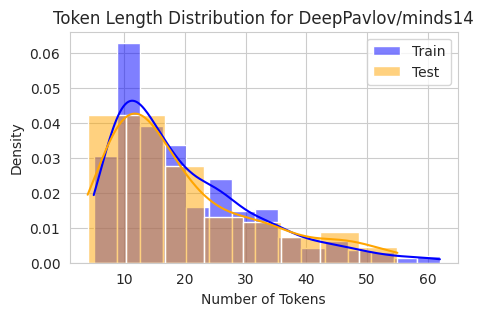

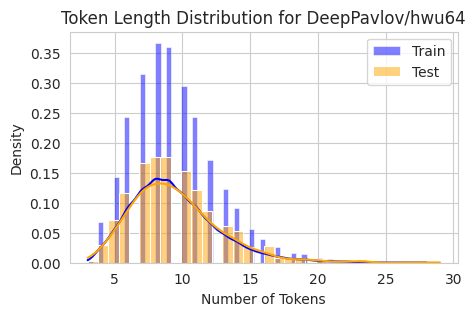

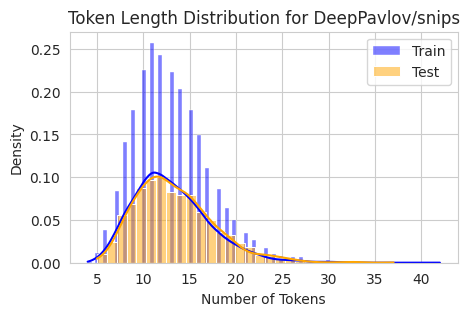

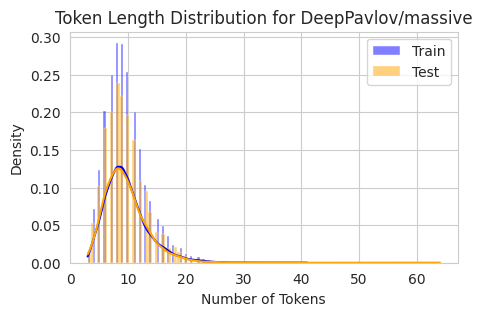

In [44]:
plot_tokens_distributions(single_label_datasets, tokenizers_names[0])

In [15]:
def plot_average_tokens(datasets_names: list[str], tokenizers_names: list[str]):
    for name in datasets_names:
        ds = datasets.load_dataset(name)
        
        # Initialize lists to store the average token lengths and their stds
        avg_train_tokens = []
        avg_test_tokens = []
        std_train_tokens = []
        std_test_tokens = []
        
        for tokenizer_name in tokenizers_names:
            tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
            
            # Calculate the number of tokens for train and test sets
            n_tokens_train = [len(tokenizer.encode(rec["utterance"])) for rec in ds["train"]]
            n_tokens_test = [len(tokenizer.encode(rec["utterance"])) for rec in ds["test"]]
            
            # Compute the average and standard deviation
            avg_train_tokens.append(np.mean(n_tokens_train))
            avg_test_tokens.append(np.mean(n_tokens_test))
            std_train_tokens.append(np.std(n_tokens_train))
            std_test_tokens.append(np.std(n_tokens_test))
        
        # Plotting
        x = np.arange(len(tokenizers_names))
        width = 0.35
        
        plt.bar(x - width/2, avg_train_tokens, width, label='Train', yerr=std_train_tokens, capsize=5)
        plt.bar(x + width/2, avg_test_tokens, width, label='Test', yerr=std_test_tokens, capsize=5)
        
        plt.xlabel('Tokenizers')
        plt.ylabel('Average Number of Tokens')
        plt.title(f'Dataset: {name}')
        plt.xticks(x, tokenizers_names, rotation=30)
        plt.legend()
        
        # Show the plot for the current dataset
        plt.show()

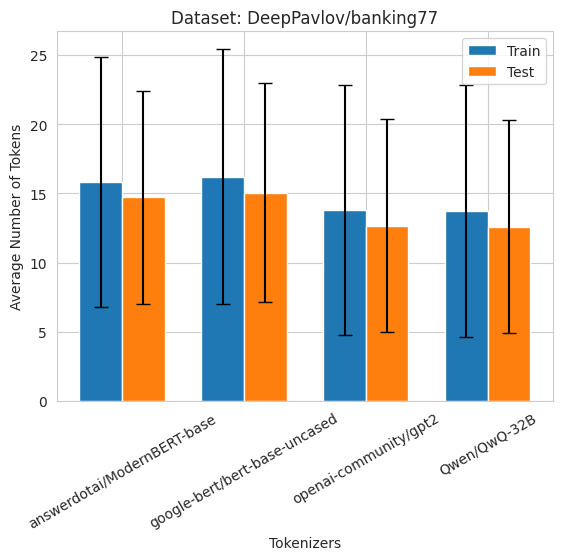

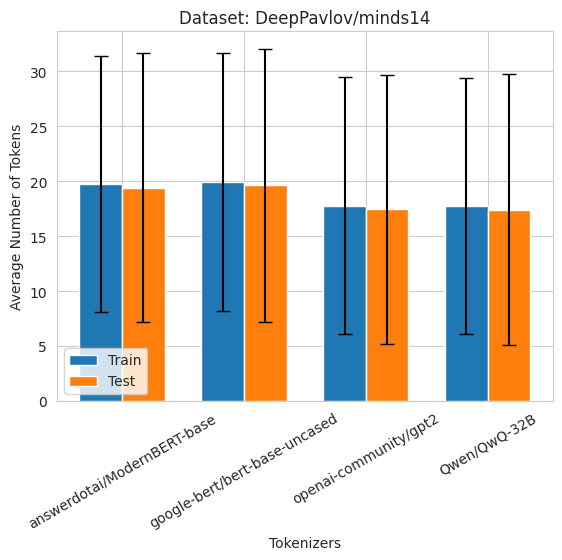

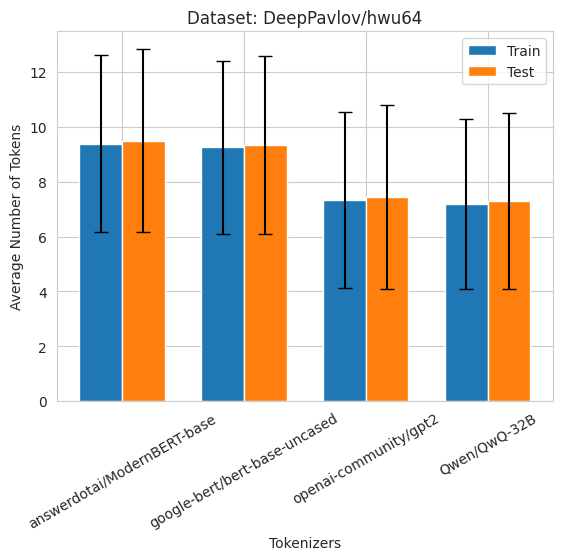

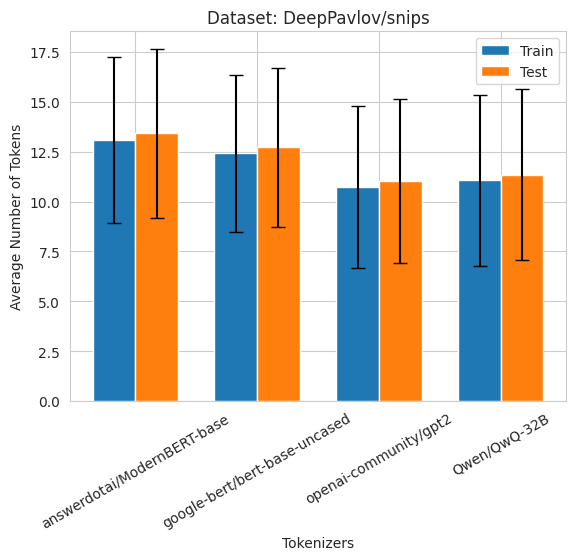

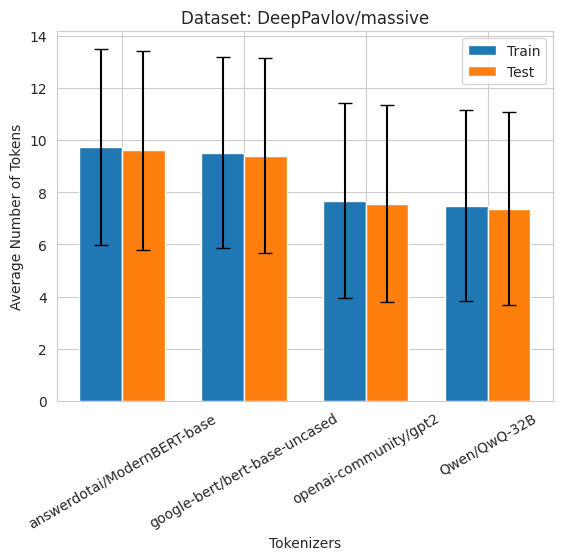

In [16]:
plot_average_tokens(single_label_datasets, tokenizers_names)

## `Длины в каждом классе`

In [13]:
def plot_classwise_average_tokens(datasets_names: list[str], tokenizer_name: str):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    for name in datasets_names:
        ds = datasets.load_dataset(name)
        
        # Initialize lists to store the average token lengths and their stds
        avg_train_tokens = []
        avg_test_tokens = []
        std_train_tokens = []
        std_test_tokens = []
        
        n_classes = get_number_of_classes(ds["train"])
        for i in range(n_classes):

            # Calculate the number of tokens for train and test sets
            n_tokens_train = [len(tokenizer.encode(rec["utterance"])) for rec in ds["train"] if rec["label"] == i]
            n_tokens_test = [len(tokenizer.encode(rec["utterance"])) for rec in ds["test"] if rec["label"] == i]
            
            # Compute the average and standard deviation
            avg_train_tokens.append(np.mean(n_tokens_train))
            avg_test_tokens.append(np.mean(n_tokens_test))
            std_train_tokens.append(np.std(n_tokens_train))
            std_test_tokens.append(np.std(n_tokens_test))
        
        # Plotting
        x = np.arange(n_classes)
        width = 0.35
        
        plt.figure(figsize=(15,4))
        plt.bar(x - width/2, avg_train_tokens, width, label='Train', yerr=std_train_tokens, capsize=5)
        plt.bar(x + width/2, avg_test_tokens, width, label='Test', yerr=std_test_tokens, capsize=5)
        
        plt.xlabel('Classes')
        plt.ylabel('Average Number of Tokens')
        plt.title(f'Dataset: {name}')
        plt.xticks(x)
        plt.legend()
        
        # Show the plot for the current dataset
        plt.show()

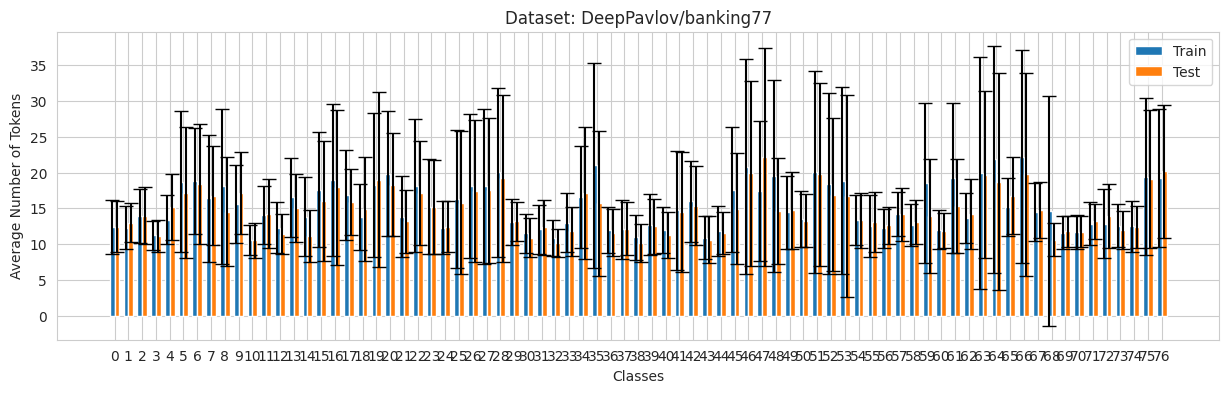

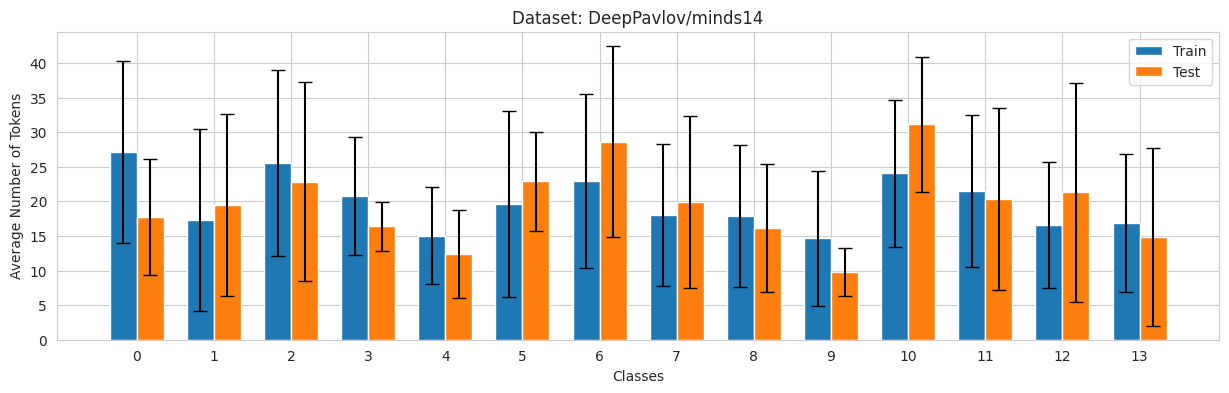

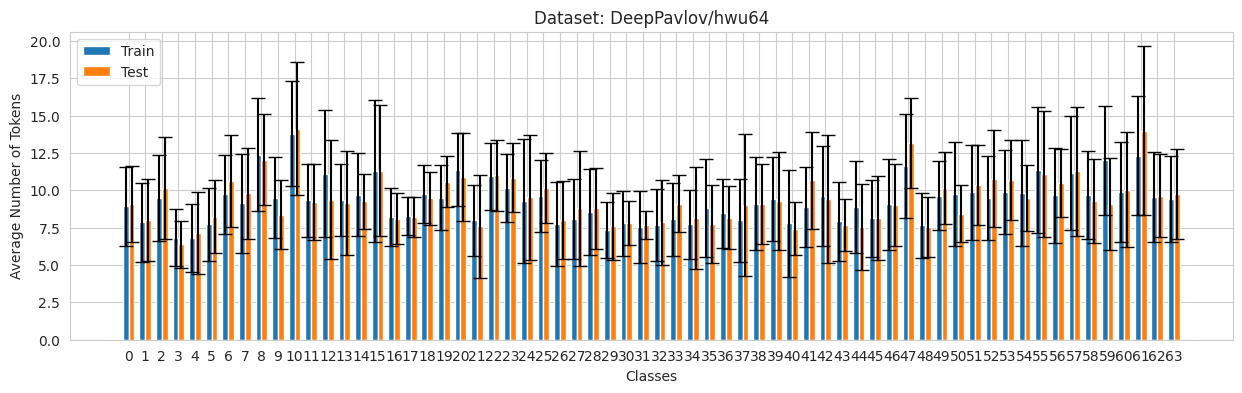

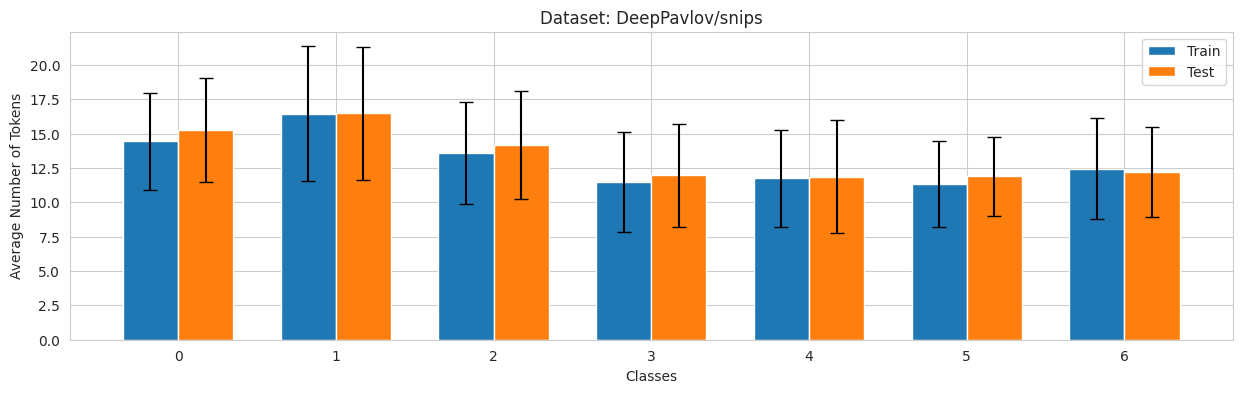

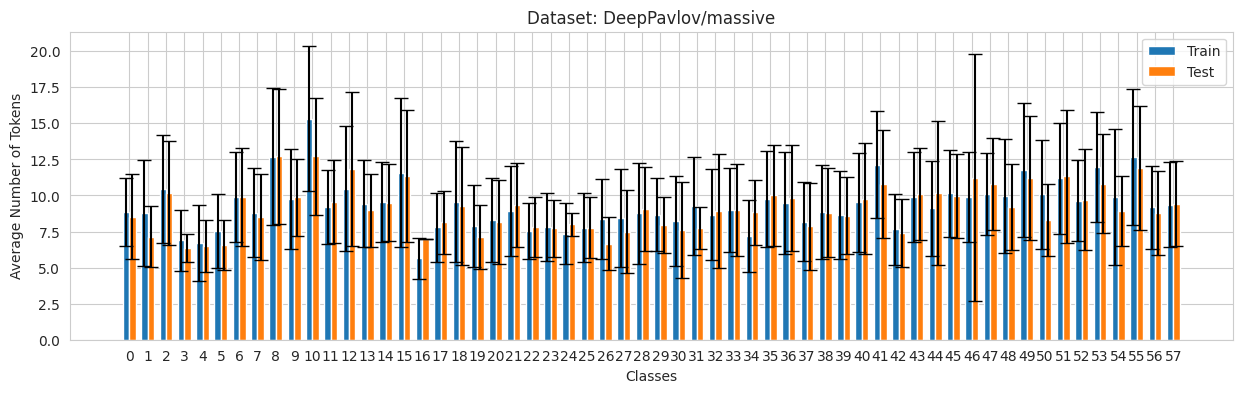

In [14]:
plot_classwise_average_tokens(single_label_datasets, tokenizers_names[0])

## `Выбросы по длинам`

In [19]:
def _find_outliers(dataset_name: str, tokenizer_name: str, k: int = 3):
    # Load the tokenizer
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    
    # Load the dataset
    ds = datasets.load_dataset(dataset_name)
    
    # Tokenize the texts and count the number of tokens
    n_tokens_train = [len(tokenizer.encode(rec["utterance"])) for rec in ds["train"]]
    n_tokens_test = [len(tokenizer.encode(rec["utterance"])) for rec in ds["test"]]
    
    # Combine train and test tokens for analysis
    all_n_tokens = n_tokens_train + n_tokens_test
    all_texts = [rec["utterance"] for rec in ds["train"]] + [rec["utterance"] for rec in ds["test"]]
    
    # Sort texts based on the number of tokens
    sorted_indices = np.argsort(all_n_tokens)
    sorted_texts = [all_texts[i] for i in sorted_indices]
    sorted_n_tokens = [all_n_tokens[i] for i in sorted_indices]
    
    # Find k shortest texts
    k_shortest_texts = sorted_texts[:k]
    k_shortest_tokens = sorted_n_tokens[:k]
    
    # Find k longest texts
    k_longest_texts = sorted_texts[-k:]
    k_longest_tokens = sorted_n_tokens[-k:]
    
    # Find k texts around the median
    median_index = len(sorted_texts) // 2
    k_median_texts = sorted_texts[median_index - k//2 : median_index + k//2 + 1]
    k_median_tokens = sorted_n_tokens[median_index - k//2 : median_index + k//2 + 1]
    
    # Print the results
    print(f"{k} Shortest Texts:")
    for text, tokens in zip(k_shortest_texts, k_shortest_tokens):
        print(f"Tokens: {tokens}, Text: {text}")
    
    print(f"\n{k} Longest Texts:")
    for text, tokens in zip(k_longest_texts, k_longest_tokens):
        print(f"Tokens: {tokens}, Text: {text}")
    
    print(f"\n{k} Texts Around the Median:")
    for text, tokens in zip(k_median_texts, k_median_tokens):
        print(f"Tokens: {tokens}, Text: {text}")


In [26]:
def find_outliers(datasets_names: list[str], tokenizer_name: str, k: int = 3):
    for name in datasets_names:
        print(f"==== {name} ====", end="\n\n")
        _find_outliers(name, tokenizer_name, k)
        print()

In [27]:
find_outliers(single_label_datasets, tokenizers_names[0], k=3)

==== DeepPavlov/banking77 ====

3 Shortest Texts:
Tokens: 4, Text: Supported countries
Tokens: 4, Text: Lost password
Tokens: 4, Text: Change currency

3 Longest Texts:
Tokens: 90, Text: Hearing about your verification results from us may take anywhere from 10 minutes to approximately one hour.  If this verification has in fact, failed, double-check to make sure that your images are clear.  Also make sure that your document photos have no blur or glare. They need to be readable.  You must also be 18 years of age or older and be a resident of Switzerland or the European Economic Area to open an account.
Tokens: 93, Text: Hi! I'm a university student studying abroad and I noticed that when I was trying to cross-reference my budget for this month that there were extra fees I was not expecting. Why is that? I've had this account for years and I haven't had any trouble so far, it might not even be on your all's end since I'm still new to international travel and finance, but I wanted to dou

## `Бейзлайн`

In [45]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
)
from tabulate import tabulate

def check_baseline(datasets_names: list[str]):
    # Initialize a dictionary to store metrics for each dataset
    results = []

    for name in datasets_names:
        ds = datasets.load_dataset(name)
        train_utterances = ds["train"]["utterance"]
        test_utterances = ds["test"]["utterance"]
        train_labels = ds["train"]["label"]
        test_labels = ds["test"]["label"]
        
        # TF-IDF Vectorization
        vectorizer = TfidfVectorizer()
        X_train = vectorizer.fit_transform(train_utterances)
        X_test = vectorizer.transform(test_utterances)
        
        # Logistic Regression with Cross-Validation
        model = LogisticRegressionCV(cv=3, max_iter=300)
        model.fit(X_train, train_labels)
        
        # Predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(test_labels, y_pred)
        macro_roc_auc = roc_auc_score(test_labels, y_pred_proba, multi_class='ovo', average='macro')
        macro_f1 = f1_score(test_labels, y_pred, average='macro')
        micro_f1 = f1_score(test_labels, y_pred, average='micro')
        macro_recall = recall_score(test_labels, y_pred, average='macro')
        micro_recall = recall_score(test_labels, y_pred, average='micro')
        macro_precision = precision_score(test_labels, y_pred, average='macro')
        micro_precision = precision_score(test_labels, y_pred, average='micro')
        
        # Append results for this dataset
        results.append([
            name,
            accuracy,
            macro_roc_auc,
            macro_f1,
            micro_f1,
            macro_recall,
            micro_recall,
            macro_precision,
            micro_precision,
        ])
    
    # Define table headers
    headers = [
        "Dataset",
        "Accuracy",
        "Macro ROC-AUC",
        "Macro F1",
        "Micro F1",
        "Macro Recall",
        "Micro Recall",
        "Macro Precision",
        "Micro Precision",
    ]
    
    # Print the table
    print(tabulate(results, headers=headers, tablefmt="grid", floatfmt=".4f"))

In [46]:
check_baseline(single_label_datasets)

+----------------------+------------+-----------------+------------+------------+----------------+----------------+-------------------+-------------------+
| Dataset              |   Accuracy |   Macro ROC-AUC |   Macro F1 |   Micro F1 |   Macro Recall |   Micro Recall |   Macro Precision |   Micro Precision |
+======================+============+=================+============+============+================+================+===================+===================+
| DeepPavlov/banking77 |     0.8971 |          0.9980 |     0.8973 |     0.8971 |         0.8971 |         0.8971 |            0.9016 |            0.8971 |
+----------------------+------------+-----------------+------------+------------+----------------+----------------+-------------------+-------------------+
| DeepPavlov/minds14   |     0.9444 |          0.9992 |     0.9409 |     0.9444 |         0.9446 |         0.9444 |            0.9512 |            0.9444 |
+----------------------+------------+-----------------+---------